# Import

In [152]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np
from sklearn.preprocessing import OrdinalEncoder , StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


## Config

In [153]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled memory growth for {gpu}")
    except Exception as e:
        print(e)

# Functions

In [154]:
global_split_index_1 = 0
global_split_index_2 = 0

In [155]:
def make_ds(series, seq_length, batch_size, target, shuffle=False):
    x = series.drop(columns=target).to_numpy()
    y = series[target].to_numpy().astype("float32")    # always slice from the numpy array
    y = y[seq_length:]

    return tf.keras.utils.timeseries_dataset_from_array(
        data=x,
        targets=y,
        sequence_length=seq_length,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42
    )

def train_valid_test_split(df, train_pct=0.80, valid_pct=0.10):

    split_index_1 = int(len(df) * train_pct)
    split_index_2 = int(len(df) * (train_pct+valid_pct))

    global global_split_index_1
    global global_split_index_2

    global_split_index_1 = split_index_1
    global_split_index_2 = split_index_2

    train_df = df.iloc[:split_index_1].copy()
    valid_df = df.iloc[split_index_1:split_index_2].copy()
    test_df = df.iloc[split_index_2:].copy()


    print(f"""
        split index 1: {split_index_1}
        split index 2: {split_index_2}""")
    return (train_df, valid_df, test_df)

def reuse_split(df):

    global global_split_index_1
    global global_split_index_2

    train_df = df.iloc[:global_split_index_1].copy()
    valid_df = df.iloc[global_split_index_1:global_split_index_2].copy()
    test_df = df.iloc[global_split_index_2:].copy()

    return (train_df, valid_df, test_df)

# Load Data

In [156]:
Lemans_2022_2021_7_Toyota = pd.read_csv("Leman 2022 2021 7 Toyota.csv")

# Filters

In [157]:
Lemans_2022_2021_7_Toyota.columns

Index(['field1', 'number', 'driver_number', 'lap_number', 'lap_time',
       'lap_improvement', 'crossing_finish_line_in_pit', 's1',
       's1_improvement', 's2', 's2_improvement', 's3', 's3_improvement', 'kph',
       'elapsed', 'hour', 's1_large', 's2_large', 's3_large', 'top_speed',
       'driver_name', 'pit_time', 'class', 'group', 'team', 'manufacturer',
       'season', 'circuit', 'round', 'vehicle', 'flag_at_fl', 'team_no',
       'lap_time_ms', 'lap_time_s', 'engine', 'driver_stint_no',
       'driver_stint', 'team_stint_no', 'team_stint', 'elapsed_ms', 'position',
       'class_position', 'interval_ms', 'interval', 'gap', 'class_interval',
       'class_gap', 'elapsed_s'],
      dtype='object')

In [158]:
Race_df = Lemans_2022_2021_7_Toyota.copy()

# Race_df = Race_df[["driver_number","lap_number","s1","s2","s3","flag_at_fl","interval",'crossing_finish_line_in_pit']]
Race_df = Race_df[["driver_number","lap_number","s1","s2","s3","interval",'crossing_finish_line_in_pit']]

Race_df["crossing_finish_line_in_pit"].replace("B",1,inplace = True)
Race_df["crossing_finish_line_in_pit"].fillna(0,inplace = True)
# Race_df["flag_at_fl"].fillna("YF",inplace = True)

/tmp/ipykernel_1281519/3279009836.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Race_df["crossing_finish_line_in_pit"].replace("B",1,inplace = True)
/tmp/ipykernel_1281519/3279009836.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Race_df["crossing_finish_line_in_pit"].replace("B",1,inplac

# column management

In [159]:
Race_df 

,driver_number,lap_number,s1,s2,s3,interval,crossing_finish_line_in_pit
0,1,1,63.835,155.718,172.772,0.000,0.0
1,1,2,54.893,124.211,198.541,301.806,0.0
2,1,3,43.594,91.764,114.925,217.355,0.0
3,1,4,39.376,154.086,113.503,37.439,0.0
4,1,5,39.471,90.347,113.535,19.538,0.0
...,...,...,...,...,...,...,...
746,3,376,33.237,80.788,95.770,128.109,0.0
747,3,377,33.765,80.346,95.705,119.461,0.0
748,3,378,33.645,80.892,98.264,121.119,0.0
749,3,379,34.550,81.034,97.764,122.157,0.0


## normalising targets

In [160]:
# for col in ["s1", "s2", "s3",]:
#     col_mean = Race_df[col].mean()
#     col_std = Race_df[col].std()

#     Race_df[col] = (Race_df[col] - col_mean) / col_std


In [161]:
for col in ["s1", "s2", "s3",]:
    window_size = 10

    baseline = Race_df[col].rolling(window=window_size, min_periods=1).mean()
    flag_level = 1.10 * baseline
    flag_col = col + "_yellow_flag"    
    Race_df[flag_col] = (Race_df[col] > flag_level).astype(int)

    # clip_level = 1.10 * baseline
    # Race_df[col] = Race_df[col].clip(upper=clip_level)



# Splitting

In [162]:
Train_test_valid_sector1_df = Race_df.copy()
Train_test_valid_sector2_df = Race_df.copy()
Train_test_valid_sector3_df = Race_df.copy()

Train_test_valid_sector1_df = Train_test_valid_sector1_df.drop(columns=["s2","s3"])
Train_test_valid_sector2_df = Train_test_valid_sector2_df.drop(columns=["s1","s3"])
Train_test_valid_sector3_df = Train_test_valid_sector3_df.drop(columns=["s1","s2"])



old version of sliptting below now we are using one race session as test  and all previous sessions including previous races as train

In [163]:
train_sector1, valid_sector1, test_sector1 = train_valid_test_split(Train_test_valid_sector1_df)
train_sector2, valid_sector2, test_sector2 = reuse_split(Train_test_valid_sector2_df,)
train_sector3, valid_sector3, test_sector3 = reuse_split(Train_test_valid_sector3_df)



        split index 1: 600
        split index 2: 675


# Encoding and numerical formatting

In [164]:
ints_that_should_not_be_floats = []
categorical_cols = ["driver_number"]

ordinal_encoder_1 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            # all unseen categories map to -1
    encoded_missing_value=-2     # missing values map to -2
)
ordinal_encoder_2 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            
    encoded_missing_value=-2     
)
ordinal_encoder_3 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            
    encoded_missing_value=-2    
)

## S1

ordinal_encoder_1.fit(train_sector1[categorical_cols])

train_sector1[categorical_cols] = ordinal_encoder_1.transform(train_sector1[categorical_cols]).astype("int32")
train_sector1[ints_that_should_not_be_floats] = train_sector1[ints_that_should_not_be_floats].astype("int32")

valid_sector1[categorical_cols] = ordinal_encoder_1.transform(valid_sector1[categorical_cols]).astype("int32")
valid_sector1[ints_that_should_not_be_floats] = valid_sector1[ints_that_should_not_be_floats].astype("int32")

test_sector1[categorical_cols] = ordinal_encoder_1.transform(test_sector1[categorical_cols]).astype("int32")
test_sector1[ints_that_should_not_be_floats] = test_sector1[ints_that_should_not_be_floats].astype("int32")

## S2

ordinal_encoder_2.fit(train_sector2[categorical_cols])

train_sector2[categorical_cols] = ordinal_encoder_2.transform(train_sector2[categorical_cols]).astype("int32")
train_sector2[ints_that_should_not_be_floats] = train_sector2[ints_that_should_not_be_floats].astype("int32")

valid_sector2[categorical_cols] = ordinal_encoder_2.transform(valid_sector2[categorical_cols]).astype("int32")
valid_sector2[ints_that_should_not_be_floats] = valid_sector2[ints_that_should_not_be_floats].astype("int32")

test_sector2[categorical_cols] = ordinal_encoder_2.transform(test_sector2[categorical_cols]).astype("int32")
test_sector2[ints_that_should_not_be_floats] = test_sector2[ints_that_should_not_be_floats].astype("int32")

## S3

ordinal_encoder_3.fit(train_sector3[categorical_cols])

train_sector3[categorical_cols] = ordinal_encoder_3.transform(train_sector3[categorical_cols]).astype("int32")
train_sector3[ints_that_should_not_be_floats] = train_sector3[ints_that_should_not_be_floats].astype("int32")

valid_sector3[categorical_cols] = ordinal_encoder_3.transform(valid_sector3[categorical_cols]).astype("int32")
valid_sector3[ints_that_should_not_be_floats] = valid_sector3[ints_that_should_not_be_floats].astype("int32")

test_sector3[categorical_cols] = ordinal_encoder_3.transform(test_sector3[categorical_cols]).astype("int32")
test_sector3[ints_that_should_not_be_floats] = test_sector3[ints_that_should_not_be_floats].astype("int32")


In [165]:
sect_1_corr_matrix = train_sector1.corr()
sect_2_corr_matrix = train_sector2.corr()
sect_3_corr_matrix = train_sector3.corr()



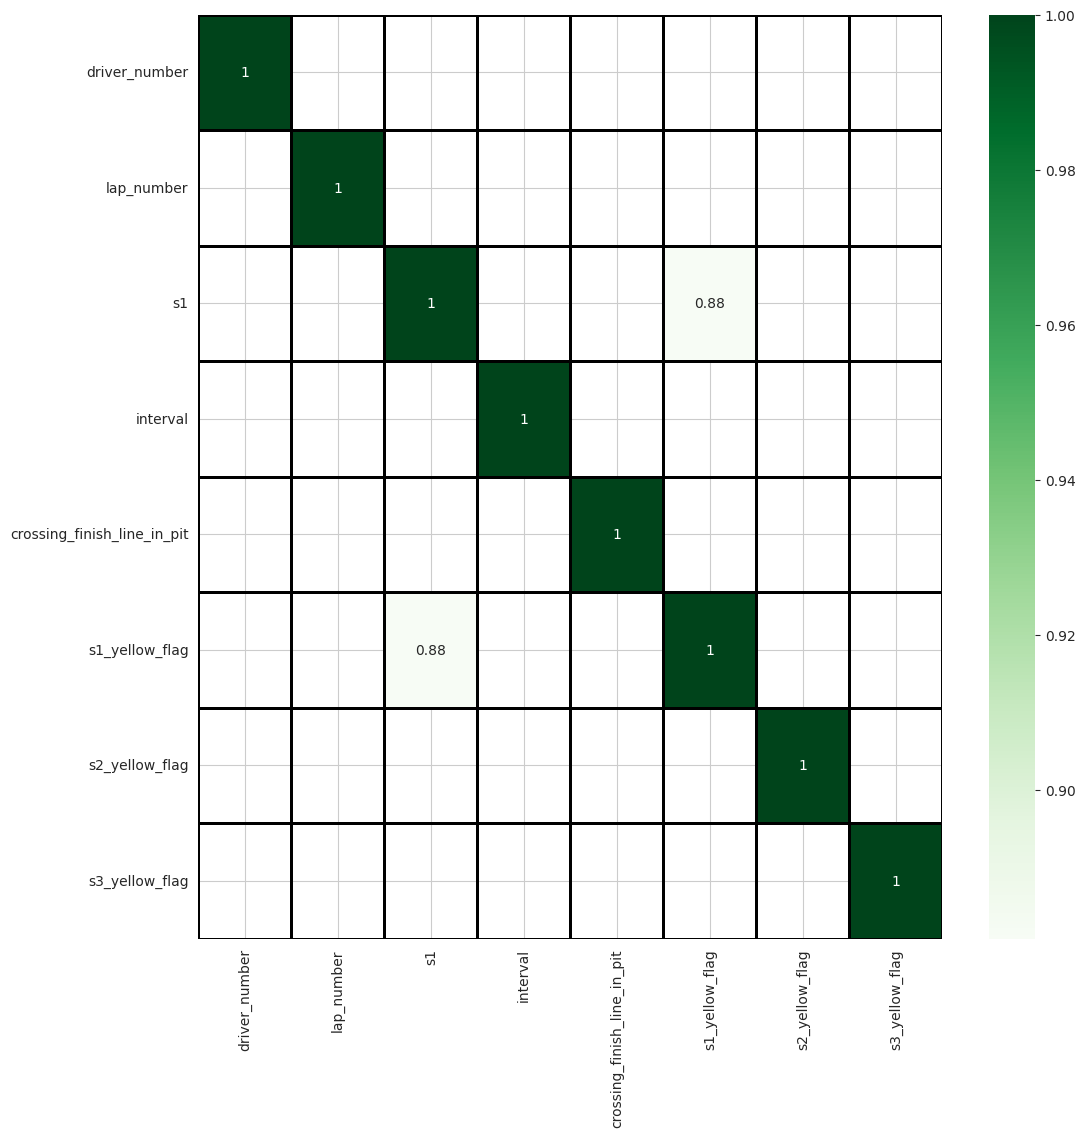

In [166]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_1_corr_matrix,
    mask = sect_1_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

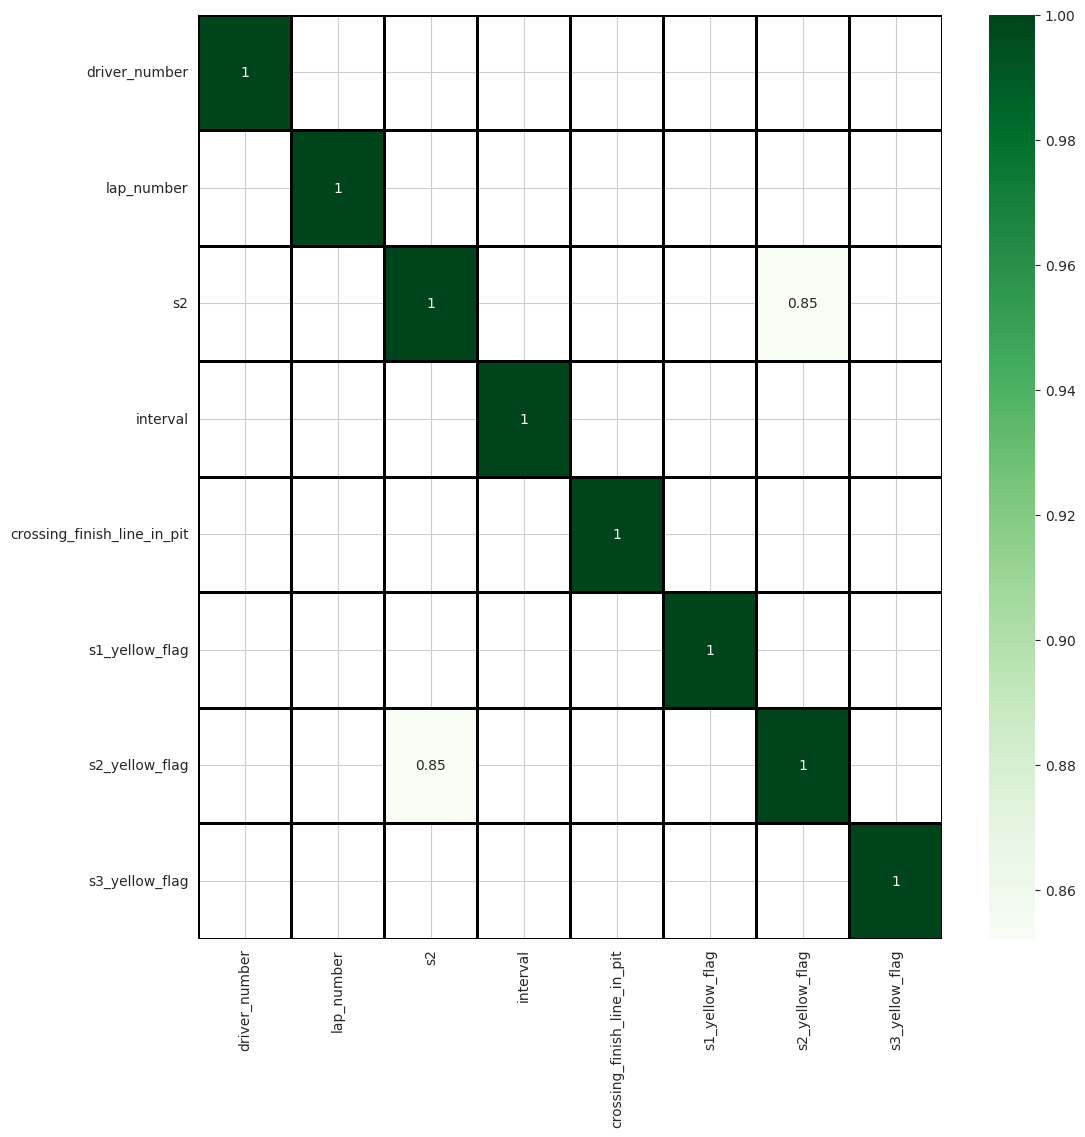

In [167]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_2_corr_matrix,
    mask = sect_2_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

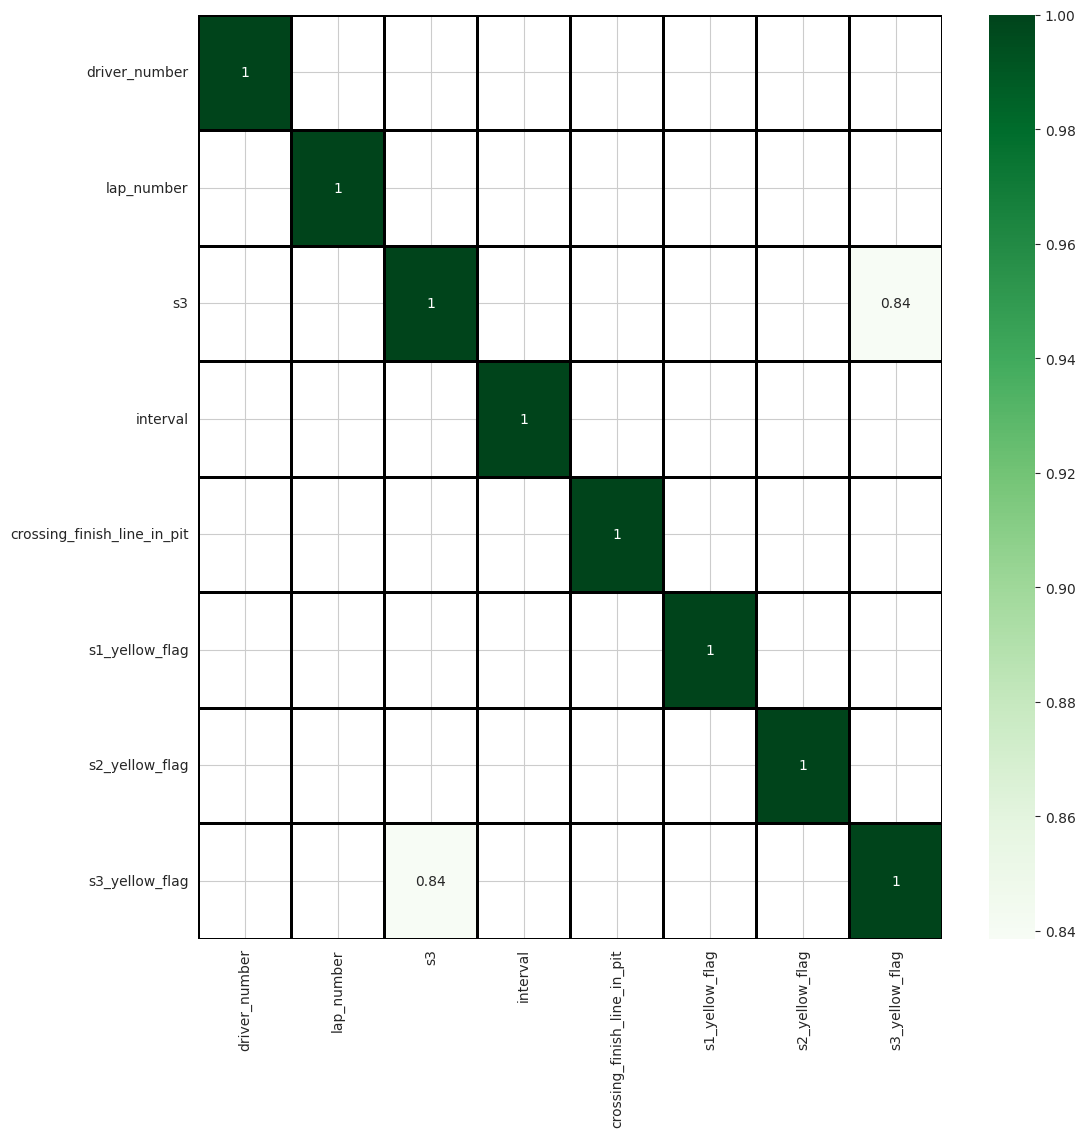

In [168]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_3_corr_matrix,
    mask = sect_3_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

‘1’: Track clear (beginning of session or to indicate the end
    of another status)

‘2’: Yellow flag (sectors are unknown)

‘3’: ??? Never seen so far, does not exist?

‘4’: Safety Car

‘5’: Red Flag

‘6’: Virtual Safety Car deployed

‘7’: Virtual Safety Car ending (As indicated on the drivers steering wheel, on tv and so on; status ‘1’ will mark the actual end)

# Scaling

In [169]:
train_sector1

,driver_number,lap_number,s1,interval,crossing_finish_line_in_pit,s1_yellow_flag,s2_yellow_flag,s3_yellow_flag
0,0,1,63.835,0.000,0.0,0,0,0
1,0,2,54.893,301.806,0.0,0,0,0
2,0,3,43.594,217.355,0.0,0,0,0
3,0,4,39.376,37.439,0.0,0,1,0
4,0,5,39.471,19.538,0.0,0,0,0
...,...,...,...,...,...,...,...,...
595,0,225,33.638,0.000,0.0,0,0,0
596,0,226,33.635,0.000,0.0,0,0,0
597,0,227,32.847,0.000,1.0,0,0,0
598,0,228,92.516,34.745,0.0,1,0,0


In [170]:
to_be_standardised = ["lap_number","interval"]

standard_scaler_1 = StandardScaler()
standard_scaler_2 = StandardScaler()        # not necessary but makes it more diffiult to perform transformations with incorectly fit scalars later 
standard_scaler_3 = StandardScaler()

## S1

standard_scaler_1.fit(train_sector1[to_be_standardised])

train_sector1[to_be_standardised] = standard_scaler_1.transform(train_sector1[to_be_standardised]) 
valid_sector1[to_be_standardised] = standard_scaler_1.transform(valid_sector1[to_be_standardised])
test_sector1[to_be_standardised] = standard_scaler_1.transform(test_sector1[to_be_standardised]) 

## S2

standard_scaler_2.fit(train_sector2[to_be_standardised])

train_sector2[to_be_standardised] = standard_scaler_2.transform(train_sector2[to_be_standardised]) 
valid_sector2[to_be_standardised] = standard_scaler_2.transform(valid_sector2[to_be_standardised])
test_sector2[to_be_standardised] = standard_scaler_2.transform(test_sector2[to_be_standardised]) 

## S3

standard_scaler_3.fit(train_sector3[to_be_standardised])

train_sector3[to_be_standardised] = standard_scaler_3.transform(train_sector3[to_be_standardised]) 
valid_sector3[to_be_standardised] = standard_scaler_3.transform(valid_sector3[to_be_standardised])
test_sector3[to_be_standardised] = standard_scaler_3.transform(test_sector3[to_be_standardised]) 

In [171]:
standard_scaler_target_1 = StandardScaler()
standard_scaler_target_2 = StandardScaler()        
standard_scaler_target_3 = StandardScaler()


train_sector1['s1'] = standard_scaler_target_1.fit_transform(train_sector1[['s1']])
valid_sector1['s1'] = standard_scaler_target_1.transform(valid_sector1[['s1']])
test_sector1['s1'] = standard_scaler_target_1.transform(test_sector1[['s1']])



train_sector2['s2'] = standard_scaler_target_2.fit_transform(train_sector2[['s2']])
valid_sector2['s2'] = standard_scaler_target_2.transform(valid_sector2[['s2']])
test_sector2['s2'] = standard_scaler_target_2.transform(test_sector2[['s2']])

train_sector3['s3'] = standard_scaler_target_3.fit_transform(train_sector3[['s3']])
valid_sector3['s3'] = standard_scaler_target_3.transform(valid_sector3[['s3']])
test_sector3['s3'] = standard_scaler_target_3.transform(test_sector3[['s3']])


# Seq length and bathc size

In [172]:
seq_length = 24
batchsize = 32

# datasets

In [173]:
train_sector1_ds = make_ds(train_sector1, seq_length, batchsize, "s1", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
valid_sector1_ds = make_ds(valid_sector1, seq_length, batchsize, "s1", shuffle=False)
test_sector1_ds = make_ds(test_sector1, seq_length, batchsize, "s1", shuffle=False)

train_sector2_ds = make_ds(train_sector2, seq_length, batchsize, "s2", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
valid_sector2_ds = make_ds(valid_sector2, seq_length, batchsize, "s2", shuffle=False)
test_sector2_ds = make_ds(test_sector2, seq_length, batchsize, "s2", shuffle=False)

train_sector3_ds = make_ds(train_sector3, seq_length, batchsize, "s3", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
valid_sector3_ds = make_ds(valid_sector3, seq_length, batchsize, "s3", shuffle=False)
test_sector3_ds = make_ds(test_sector3, seq_length, batchsize, "s3", shuffle=False)


# Sanity Checks

In [174]:
for batch_x, batch_y in train_sector1_ds.take(1):          # takes firs t batch of datset
    print("X shape S1:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S1:", batch_y.shape)                        # (viable windows) for single target

for batch_x, batch_y in valid_sector1_ds.take(1):
    print("X shape S2:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S2:", batch_y.shape)                        # (viable windows,) for single target

for batch_x, batch_y in test_sector1_ds.take(1):
    print("X shape S3:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S3:", batch_y.shape)                        # (viable windows,) for single target

X shape S1: (32, 24, 7)
y shape S1: (32,)
X shape S2: (32, 24, 7)
y shape S2: (32,)
X shape S3: (32, 24, 7)
y shape S3: (32,)


In [175]:
# Get the first window and its target

for batch_x, batch_y in train_sector1_ds.take(1):
    first_window = batch_x[0].numpy()
    first_target = batch_y[0].numpy()
    print("First window last row (features):", first_window[-1])
    print("First target (Sector1Time):", first_target)


First window last row (features): [ 0.          0.58244628 -0.28322691  0.          0.          0.
  1.        ]
First target (Sector1Time): -0.37013373


2026-03-13 00:21:11.397740: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [176]:
print("train windows:", tf.data.experimental.cardinality(train_sector1_ds))
print("valid windows:", tf.data.experimental.cardinality(valid_sector1_ds))
print("test  windows:", tf.data.experimental.cardinality(test_sector1_ds))   


train windows: tf.Tensor(18, shape=(), dtype=int64)
valid windows: tf.Tensor(2, shape=(), dtype=int64)
test  windows: tf.Tensor(2, shape=(), dtype=int64)


# Modelling

## Architecture

## Defining the Transformer

In [177]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

class PositionEmbedding(layers.Layer):
    """
    Learnable positional embedding for fixed-length windows.
    Adds a position vector of shape (seq_len, embed_dim) to the inputs.
    """
    def __init__(self, seq_len: int, embed_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)

    def call(self, x):
        # x: (batch, seq_len, embed_dim)
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_encoding = self.pos_emb(positions)  # (seq_len, embed_dim)
        return x + pos_encoding

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "embed_dim": self.embed_dim})
        return cfg


class TransformerBlock(layers.Layer):
    """
    Pre-norm Transformer encoder block (LayerNorm -> MHA -> Dropout -> Residual -> FFN -> Residual).
    """
    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, rate: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        # Per-head dimension; embed_dim should be divisible by num_heads
        key_dim = max(1, embed_dim // num_heads)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,            # dimension per head
            output_shape=embed_dim      # project output back to embed_dim for residual add
        )
        self.drop1 = layers.Dropout(rate)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.drop2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # Pre-norm
        x = self.norm1(inputs)
        attn_output = self.attn(x, x, training=training)
        attn_output = self.drop1(attn_output, training=training)
        x = inputs + attn_output                      # residual 1

        y = self.norm2(x)
        y = self.ffn(y, training=training)
        y = self.drop2(y, training=training)
        return x + y                                  # residual 2

In [178]:
def build_transformer_regressor(seq_len: int,
                                n_features: int,
                                embed_dim: int = 64,
                                num_heads: int = 4,
                                ff_dim: int = 128,
                                num_blocks: int = 2,
                                dropout: float = 0.1):
    """
    Returns a Keras model that takes (seq_len, n_features) and outputs a single scalar.
    """
    inputs = Input(shape=(seq_len, n_features))               # (B, T, F)

    # Project raw features to model dimension first so residuals are well-formed
    x = layers.Dense(embed_dim, name="feature_projection")(inputs)  # (B, T, E)

    # Add positional information
    x = PositionEmbedding(seq_len, embed_dim, name="positional_embedding")(x)

    # Stack N Transformer encoder blocks
    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, name=f"encoder_block_{i+1}")(x)

    # Normalise once at the end
    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)

    # Option 1: use the last token (matches RNN patterns)
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_token")(x)

    # Option 2 (alternative): GlobalAveragePooling1D to aggregate all timesteps
    # x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, name="regression_head")(x)

    model = Model(inputs, outputs, name="transformer_time_series_regressor")
    return model

## Build Transformers 

In [179]:
# sector_1_model = build_transformer_regressor(seq_length,len(train_sector1.columns)-1)
# sector_2_model = build_transformer_regressor(seq_length,len(train_sector1.columns)-1)
# sector_3_model = build_transformer_regressor(seq_length,len(train_sector1.columns)-1)

## Defining the TSMixer

In [180]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

class TSMixerBlock(layers.Layer):
    """
    TSMixer block that preserves (B, T, F) across residuals.
    - Temporal mix: MLP over time axis (after transpose to make T the last dim), returns to T.
    - Feature mix:  MLP over feature axis, returns to F.
    """
    def __init__(self,
                 time_mlp_units: int = 64,
                 feature_mlp_units: int = 64,
                 dropout: float = 0.1,
                 **kwargs):
        super().__init__(**kwargs)
        self.time_mlp_units = time_mlp_units
        self.feature_mlp_units = feature_mlp_units
        self.dropout = layers.Dropout(dropout)

        # Pre-norms
        self.norm_time = layers.LayerNormalization(epsilon=1e-6)
        self.norm_feat = layers.LayerNormalization(epsilon=1e-6)

        # Temporal mixer (applied on (B,F,T))
        self.time_dense_1 = layers.Dense(time_mlp_units, activation="gelu")
        self.time_dense_2 = None   # will be Dense(T) in build()

        # Feature mixer (applied on (B,T,F))
        self.feature_dense_1 = layers.Dense(feature_mlp_units, activation="gelu")
        self.feature_dense_2 = None  # will be Dense(F) in build()

    def build(self, input_shape):
        # input_shape = (B, T, F)
        _, T, F = input_shape

        # Return to original sizes for residual adds
        self.time_dense_2 = layers.Dense(T)   # back to time length T
        self.feature_dense_2 = layers.Dense(F)  # back to feature size F

        super().build(input_shape)

    def call(self, x, training=None):
        # ----- Temporal mixing: mix over time axis -----
        t = self.norm_time(x)                         # (B, T, F)
        t = tf.transpose(t, perm=[0, 2, 1])          # (B, F, T)  → Dense acts on last axis (T)
        t = self.time_dense_1(t)                     # (B, F, Ht)
        t = self.time_dense_2(t)                     # (B, F, T)
        t = tf.transpose(t, perm=[0, 2, 1])          # (B, T, F)
        t = self.dropout(t, training=training)
        x = x + t                                     # residual, shapes now match

        # ----- Feature mixing: mix over feature axis -----
        f = self.norm_feat(x)                        # (B, T, F)
        f = self.feature_dense_1(f)                  # (B, T, Hf)
        f = self.feature_dense_2(f)                  # (B, T, F)
        f = self.dropout(f, training=training)
        x = x + f                                     # residual

        return x


def build_tsmixer_regressor(seq_len: int,
                            n_features: int,
                            depth: int = 3,
                            time_mlp_units: int = 64,
                            feature_mlp_units: int = 64,
                            dropout: float = 0.1):
    """
    (seq_len, n_features) → scalar. Uses last timestep representation for regression head.
    """
    inputs = Input(shape=(seq_len, n_features))  # (B, T, F)
    x = inputs

    for i in range(depth):
        x = TSMixerBlock(
            time_mlp_units=time_mlp_units,
            feature_mlp_units=feature_mlp_units,
            dropout=dropout,
            name=f"tsmixer_block_{i+1}",
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_token")(x)  # (B, F)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, name="regression_head")(x)

    return Model(inputs, outputs, name="tsmixer_time_series_regressor")

## Build TSMixers

In [181]:
# # Build TSMixer models (note the corrected n_features per sector)
# sector_1_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(train_sector1.columns) - 1,   # drop the single target
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

# sector_2_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(train_sector2.columns) - 1,   # <-- was sector1 by mistake
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

# sector_3_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(train_sector3.columns) - 1,   # <-- was sector1 by mistake
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

### Sector 1 model

In [182]:
sector_1_model = tf.keras.Sequential([
   tf.keras.layers.InputLayer(shape=(seq_length, len(train_sector1.columns)-1)),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
    ),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="causal",
        use_bias=False,
        activation="relu",
    ),
    tf.keras.layers.LayerNormalization(),
        tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
    ),
    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        use_bias=False,
        activation="relu",
    ),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.SpatialDropout1D(0.1),

    tf.keras.layers.LSTM(128, return_sequences=True),                                      ## return sequences is needed otherwise only last hidden state is returned                           
    tf.keras.layers.LSTM(64),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
  
    
    tf.keras.layers.Dense(1)

])    

### Sector 2 model

In [183]:
sector_2_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(seq_length, len(train_sector2.columns)-1)),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
    ),
    tf.keras.layers.LayerNormalization(),
        tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
    ),
    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        use_bias=False,
        activation="relu",
    ),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.SpatialDropout1D(0.1),

    tf.keras.layers.LSTM(128, return_sequences=True),                                      ## return sequences is needed otherwise only last hidden state is returned                           
    tf.keras.layers.LSTM(64),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
  
    
    tf.keras.layers.Dense(1)

])  

### Sector 3 model

In [184]:
sector_3_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(seq_length, len(train_sector3.columns)-1)),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
    ),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="causal",
        use_bias=False,
        activation="relu",
    ),
    tf.keras.layers.LayerNormalization(),
        tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
    ),
    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        use_bias=False,
        activation="relu",
    ),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.SpatialDropout1D(0.1),

    tf.keras.layers.LSTM(128, return_sequences=True),                                      ## return sequences is needed otherwise only last hidden state is returned                           
    tf.keras.layers.LSTM(64),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
  
    
    tf.keras.layers.Dense(1)

])   

**Effective receptive field of the cnn layers = the sum of the kernel sizes - the number of layers. This really should be less than sequence length to avoid delayed reactions.**

## Running Models

### Sector 1

In [185]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=50,
    restore_best_weights=True)


lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.01,
    first_decay_steps=150,
    t_mul=2.0,
    m_mul=0.8,
    alpha=1e-4
)

# reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor="val_mae",
#     factor=0.5,          # reduce LR by half
#     patience=10,         # wait this many epochs without improvement
#     min_lr=2e-6,         # floor
#     verbose=1
# )

opt = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

sector_1_model.compile(
    loss=tf.keras.losses.Huber(delta=1),                    ## delta is the threshold  below whise loss is mse and above acts as mae
    optimizer=opt,
    metrics=["mae"])

history = sector_1_model.fit(
    train_sector1_ds,
    validation_data = valid_sector1_ds,
    callbacks = [early_stopping_cb],
    epochs=1000)

Epoch 1/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.3898 - mae: 0.6493 - val_loss: 0.3207 - val_mae: 0.5746
Epoch 2/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2758 - mae: 0.4887 - val_loss: 0.3234 - val_mae: 0.5893
Epoch 3/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2719 - mae: 0.4697 - val_loss: 0.3138 - val_mae: 0.5229
Epoch 4/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2699 - mae: 0.4885 - val_loss: 0.3106 - val_mae: 0.4767
Epoch 5/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2698 - mae: 0.4577 - val_loss: 0.3132 - val_mae: 0.5170
Epoch 6/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2684 - mae: 0.4657 - val_loss: 0.3115 - val_mae: 0.4957
Epoch 7/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2693 - mae: 0.4459 - val_loss: 0.3114 - val_mae: 0.4935
Epoch 8/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2689 - mae: 0.4511 - val_loss: 0.3117 - val_mae: 0.4989
Epoch 9/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/

### Sector 2

In [186]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=50,
    restore_best_weights=True)

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.01,
    first_decay_steps=150,
    t_mul=2.0,
    m_mul=0.8,
    alpha=1e-4
)

# reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor="val_mae",
#     factor=0.5,          # reduce LR by half
#     patience=10,         # wait this many epochs without improvement
#     min_lr=2e-6,         # floor
#     verbose=1
# )


opt = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

sector_2_model.compile(
    loss=tf.keras.losses.Huber(delta=1),                    ## delta is the threshold  below whise loss is mse and above acts as mae
    optimizer=opt,
    metrics=["mae"])

history = sector_2_model.fit(
    train_sector2_ds,
    validation_data = valid_sector2_ds,
    callbacks = [early_stopping_cb],
    epochs=1000)

Epoch 1/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.3321 - mae: 0.5474 - val_loss: 1.8487 - val_mae: 2.1221
Epoch 2/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1802 - mae: 0.2932 - val_loss: 1.8822 - val_mae: 2.1161
Epoch 3/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1799 - mae: 0.2948 - val_loss: 1.8559 - val_mae: 2.1200
Epoch 4/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1792 - mae: 0.2914 - val_loss: 1.8647 - val_mae: 2.1130
Epoch 5/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1789 - mae: 0.2844 - val_loss: 1.8606 - val_mae: 2.1131
Epoch 6/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1791 - mae: 0.2917 - val_loss: 1.8516 - val_mae: 2.1102
Epoch 7/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1778 - mae: 0.2855 - val_loss: 1.8637 - val_mae: 2.1107
Epoch 8/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1777 - mae: 0.2810 - val_loss: 1.8628 - val_mae: 2.1112
Epoch 9/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/

### Sector 3

In [187]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=50,
    restore_best_weights=True)

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.01,
    first_decay_steps=150,
    t_mul=2.0,
    m_mul=0.8,
    alpha=1e-4
)

# reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor="val_mae",
#     factor=0.5,          # reduce LR by half
#     patience=10,         # wait this many epochs without improvement
#     min_lr=2e-6,         # floor
#     verbose=1
# )



opt = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

sector_3_model.compile(
    loss=tf.keras.losses.Huber(delta=1),                    ## delta is the threshold  below whise loss is mse and above acts as mae
    optimizer=opt,
    metrics=["mae"])

history = sector_3_model.fit(
    train_sector3_ds,
    validation_data = valid_sector3_ds,
    callbacks = [early_stopping_cb],
    epochs=1000)

Epoch 1/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4524 - mae: 0.7254 - val_loss: 0.6805 - val_mae: 0.9053
Epoch 2/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2205 - mae: 0.3888 - val_loss: 0.6774 - val_mae: 0.9248
Epoch 3/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2192 - mae: 0.3901 - val_loss: 0.6764 - val_mae: 0.9299
Epoch 4/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2164 - mae: 0.3773 - val_loss: 0.6787 - val_mae: 0.9135
Epoch 5/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2174 - mae: 0.3799 - val_loss: 0.6805 - val_mae: 0.9045
Epoch 6/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2172 - mae: 0.3810 - val_loss: 0.6802 - val_mae: 0.9059
Epoch 7/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2173 - mae: 0.3834 - val_loss: 0.6802 - val_mae: 0.9058
Epoch 8/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2163 - mae: 0.3748 - val_loss: 0.6801 - val_mae: 0.9062
Epoch 9/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/

## Results

In [188]:
test_loss_1, test_mae_1 = sector_1_model.evaluate(test_sector1_ds)
print("Sector 1 Test MAE:", test_mae_1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2515 - mae: 0.4023
Sector 1 Test MAE: 0.4023479223251343


In [189]:
test_loss_2, test_mae_2 = sector_2_model.evaluate(test_sector2_ds)
print("Sector 2 Test MAE:", test_mae_2)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - mae: 0.0611
Sector 2 Test MAE: 0.061103664338588715


In [190]:
test_loss_3, test_mae_3 = sector_3_model.evaluate(test_sector3_ds)

print("Sector 3 Test MAE:", test_mae_3)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0901 - mae: 0.2474
Sector 3 Test MAE: 0.24738408625125885


In [191]:
preds_1 = sector_1_model.predict(test_sector1_ds)
preds_1 = standard_scaler_target_1.inverse_transform(preds_1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


In [192]:
preds_2 = sector_2_model.predict(test_sector2_ds)
preds_2 = standard_scaler_target_2.inverse_transform(preds_2)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


In [193]:
preds_3 = sector_3_model.predict(test_sector3_ds)
preds_3 = standard_scaler_target_3.inverse_transform(preds_3)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


# Data surgery - Stitching predictions and reality back together

testing split starts at split_index_2 and will start predicting rom row index (index_2 + sequence length)

In [194]:
global_split_index_2

675

In [195]:
Test_pred_real = Race_df.iloc[global_split_index_2+seq_length:][["lap_number","s1","s2","s3"]]       # sequence length starts at 0
Test_pred_real[["s1_pred","s2_pred","s3_pred"]] = np.hstack([preds_1,preds_2,preds_3])
Test_pred_real["lap_time"] = Test_pred_real["s1"] + Test_pred_real["s2"] + Test_pred_real["s3"]
Test_pred_real["predicted_lap_time"] = Test_pred_real["s1_pred"] + Test_pred_real["s2_pred"] + Test_pred_real["s3_pred"]

Test_pred_real["lap_pred_delta"] = abs(Test_pred_real["lap_time"] - Test_pred_real["predicted_lap_time"])
Test_pred_real["s1_pred_delta"] = abs(Test_pred_real["s1"] - Test_pred_real["s1_pred"])
Test_pred_real["s2_pred_delta"] = abs(Test_pred_real["s2"] - Test_pred_real["s2_pred"])
Test_pred_real["s3_pred_delta"] = abs(Test_pred_real["s3"] - Test_pred_real["s3_pred"])

Test_pred_real = Test_pred_real[["lap_number",
                                 "lap_time",
                                 "predicted_lap_time",
                                 "lap_pred_delta",
                                 "s1",
                                 "s1_pred",
                                 "s1_pred_delta",
                                 "s2",
                                 "s2_pred",
                                 "s2_pred_delta",
                                 "s3",
                                 "s3_pred",
                                 "s3_pred_delta",
]]

In [196]:
Test_pred_real.tail(50) 

,lap_number,lap_time,predicted_lap_time,lap_pred_delta,s1,s1_pred,s1_pred_delta,s2,s2_pred,s2_pred_delta,s3,s3_pred,s3_pred_delta
701,331,243.954,216.673676,27.280324,35.716,36.119083,0.403083,80.560,81.601181,1.041181,127.678,98.953415,28.724585
702,332,243.834,216.674881,27.159119,35.769,36.121498,0.352498,80.277,81.599388,1.322388,127.788,98.953995,28.834005
703,333,213.393,216.676361,3.283361,36.103,36.123638,0.020638,80.453,81.598450,1.145450,96.837,98.954277,2.117277
704,334,208.938,216.677948,7.739948,33.074,36.126488,3.052488,80.166,81.597229,1.431229,95.698,98.954239,3.256239
705,335,211.885,216.681244,4.796244,33.745,36.130829,2.385829,81.954,81.596291,0.357709,96.186,98.954132,2.768132
706,336,210.990,216.683807,5.693807,34.281,36.133976,1.852976,81.044,81.595886,0.551886,95.665,98.953941,3.288941
707,337,209.946,216.683212,6.737212,33.048,36.132965,3.084965,80.003,81.596077,1.593077,96.895,98.954170,2.059170
708,338,212.518,216.677032,4.159032,34.927,36.126163,1.199163,81.065,81.596283,0.531283,96.526,98.954590,2.428590
709,339,209.272,216.665710,7.393710,32.984,36.116951,3.132951,80.330,81.593674,1.263674,95.958,98.955086,2.997086
710,340,217.796,216.660736,1.135264,34.265,36.110729,1.845729,80.517,81.594765,1.077765,103.014,98.955238,4.058762


# Plots

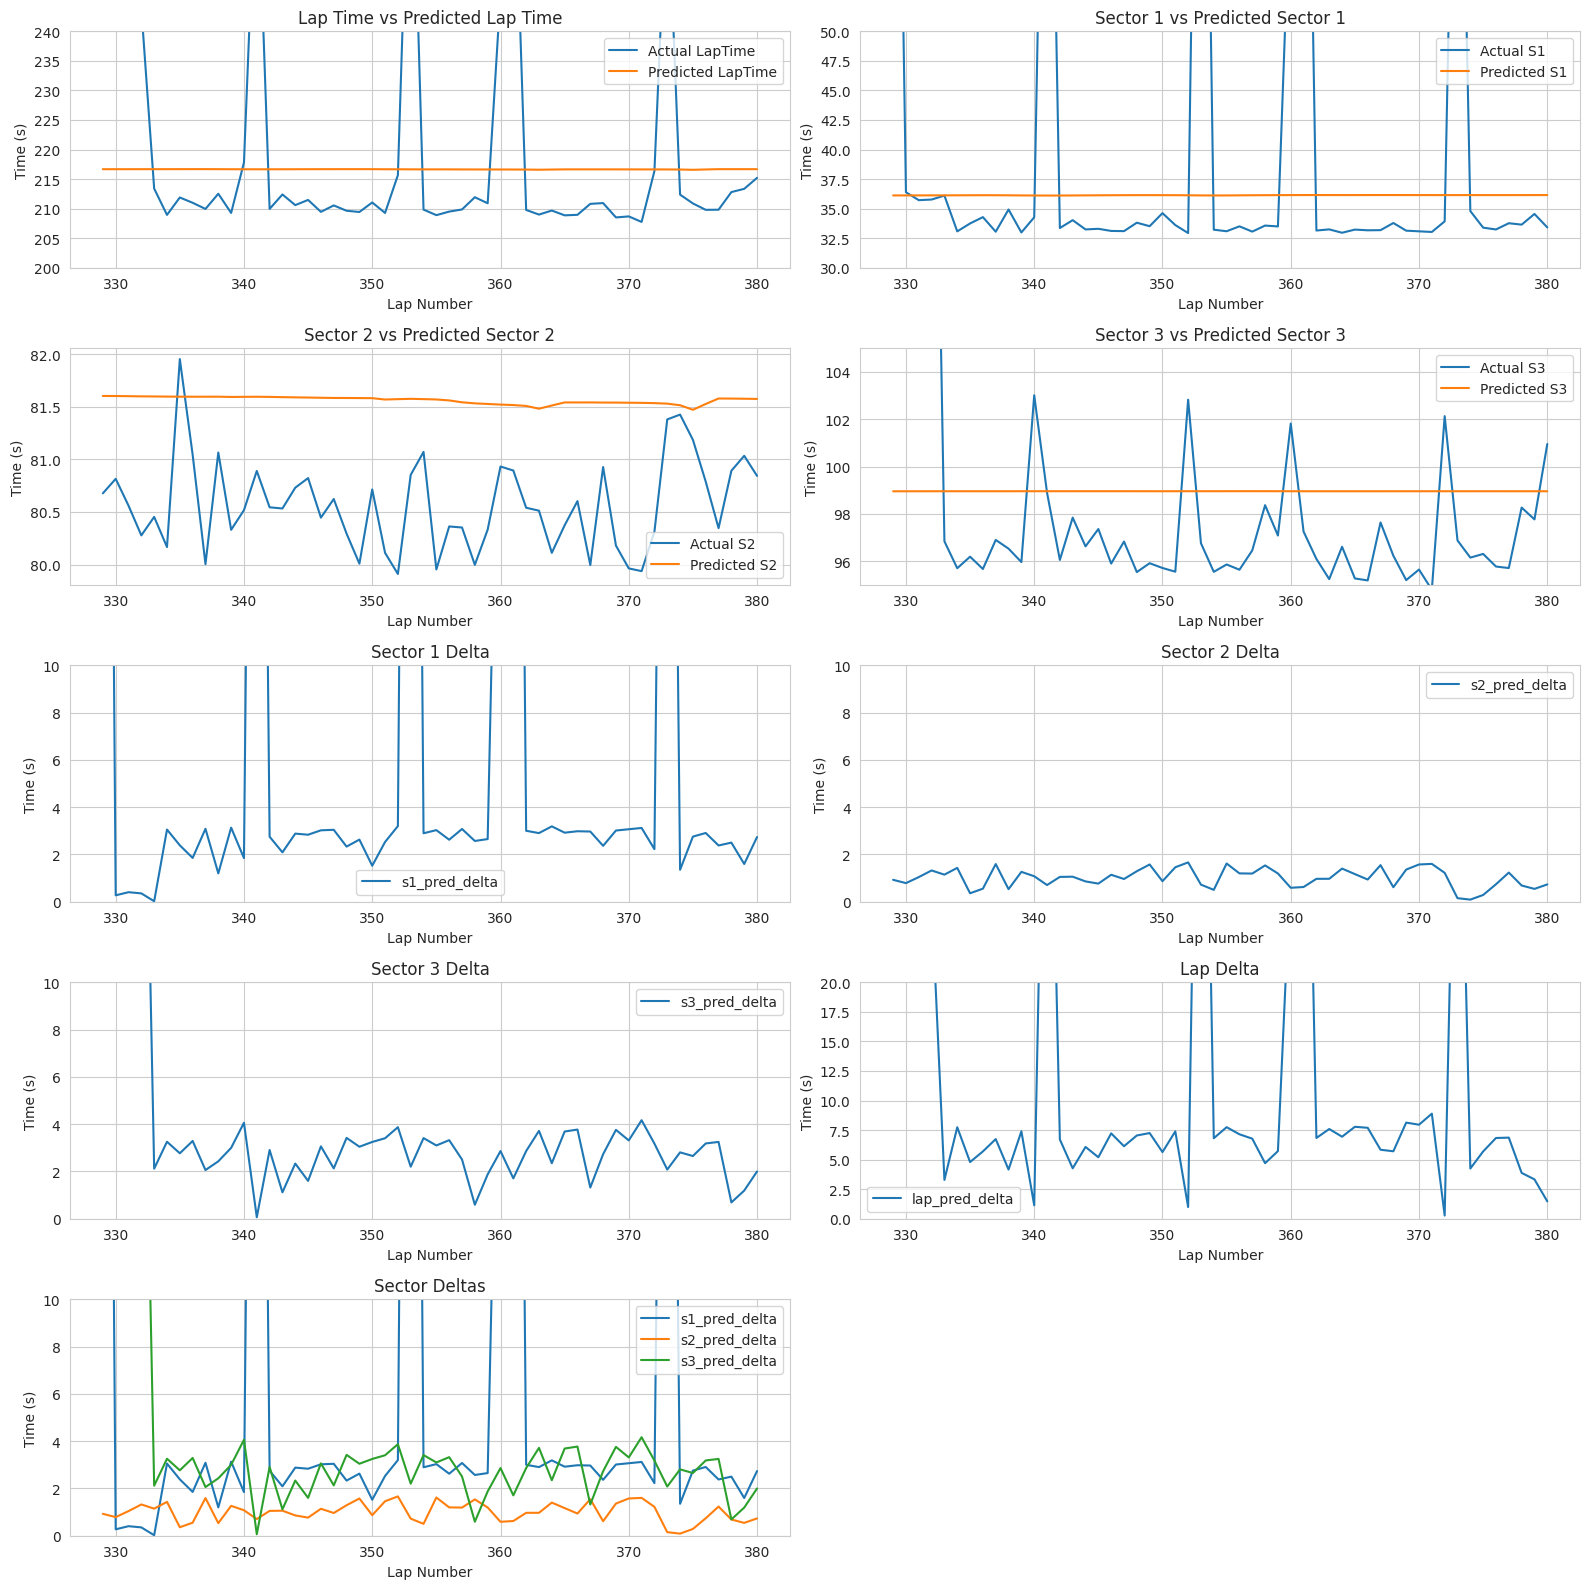

In [197]:


plt.figure(figsize=(16, 16))

# ----------------------------
# 1. LapTime vs Predicted LapTime
# ----------------------------
plt.subplot(5, 2, 1)
sns.lineplot(data=Test_pred_real, x="lap_number", y="lap_time", label="Actual LapTime")
sns.lineplot(data=Test_pred_real, x="lap_number", y="predicted_lap_time", label="Predicted LapTime")
plt.title("Lap Time vs Predicted Lap Time")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(200, 240)

# ----------------------------
# 2. Sector 1
# ----------------------------
plt.subplot(5, 2, 2)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s1", label="Actual S1")
sns.lineplot(data=Test_pred_real, x="lap_number", y="s1_pred", label="Predicted S1")
plt.title("Sector 1 vs Predicted Sector 1")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(30, 50)

# ----------------------------
# 3. Sector 2
# ----------------------------
plt.subplot(5, 2, 3)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s2", label="Actual S2")
sns.lineplot(data=Test_pred_real, x="lap_number", y="s2_pred", label="Predicted S2")
plt.title("Sector 2 vs Predicted Sector 2")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(79, 86)

# ----------------------------
# 4. Sector 3
# ----------------------------
plt.subplot(5, 2, 4)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s3", label="Actual S3")
sns.lineplot(data=Test_pred_real, x="lap_number", y="s3_pred", label="Predicted S3")
plt.title("Sector 3 vs Predicted Sector 3")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(95, 105)


# ----------------------------
# 5. Sector1 prediction deltas
# ----------------------------

plt.subplot(5, 2, 5)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s1_pred_delta", label="s1_pred_delta")
plt.title("Sector 1 Delta")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 10)

# ----------------------------
# 6. Sector2 prediction deltas
# ----------------------------

plt.subplot(5, 2, 6)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s2_pred_delta", label="s2_pred_delta")
plt.title("Sector 2 Delta")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 10)
# ----------------------------
# 7. Sector3 prediction deltas
# ----------------------------

plt.subplot(5, 2, 7)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s3_pred_delta", label="s3_pred_delta")
plt.title("Sector 3 Delta")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 10)

# ----------------------------
# 8. Lap prediction deltas
# ----------------------------

plt.subplot(5, 2, 8)
sns.lineplot(data=Test_pred_real, x="lap_number", y="lap_pred_delta", label="lap_pred_delta")
plt.title("Lap Delta")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 20)

# ----------------------------
# 9. Sectors 1,2,3 prediction deltas
# ----------------------------

plt.subplot(5, 2, 9)
sns.lineplot(data=Test_pred_real, x="lap_number", y="s1_pred_delta", label="s1_pred_delta")
sns.lineplot(data=Test_pred_real, x="lap_number", y="s2_pred_delta", label="s2_pred_delta")
sns.lineplot(data=Test_pred_real, x="lap_number", y="s3_pred_delta", label="s3_pred_delta")
plt.title("Sector Deltas")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

In [198]:
Race_df[Race_df["lap_number"].between(260,300)]

,driver_number,lap_number,s1,s2,s3,interval,crossing_finish_line_in_pit,s1_yellow_flag,s2_yellow_flag,s3_yellow_flag
259,1,260,33.247,80.671,97.358,0.000,0.0,0,0,0
260,1,261,33.337,80.447,99.837,0.000,0.0,0,0,0
261,1,262,33.259,82.073,97.407,0.000,0.0,0,0,0
262,1,263,33.227,80.441,96.886,0.000,0.0,0,0,0
263,1,264,33.244,80.627,103.312,0.000,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
666,2,296,33.075,80.165,176.493,259.502,0.0,0,0,1
667,2,297,38.002,174.350,205.614,351.805,0.0,0,1,1
668,2,298,62.284,186.740,213.273,347.154,0.0,1,1,1
669,2,299,35.849,82.899,170.884,218.719,0.0,0,0,1


# Race plot for context

In [199]:
race_overview = Lemans_2022_2021_7_Toyota[["lap_number","s1","s2","s3"]][Lemans_2022_2021_7_Toyota["season"] == 2022]

race_overview["lap_time"] = race_overview["s1"] + race_overview["s2"] + race_overview["s3"]

race_overview[["lap_time","lap_number","s1","s2","s3"]]

race_overview

,lap_number,s1,s2,s3,lap_time
371,1,59.498,81.915,98.123,239.536
372,2,63.162,80.676,97.065,240.903
373,3,33.159,80.811,95.526,209.496
374,4,32.994,80.748,95.903,209.645
375,5,33.257,80.709,96.009,209.975
...,...,...,...,...,...
746,376,33.237,80.788,95.770,209.795
747,377,33.765,80.346,95.705,209.816
748,378,33.645,80.892,98.264,212.801
749,379,34.550,81.034,97.764,213.348


(210.0, 300.0)

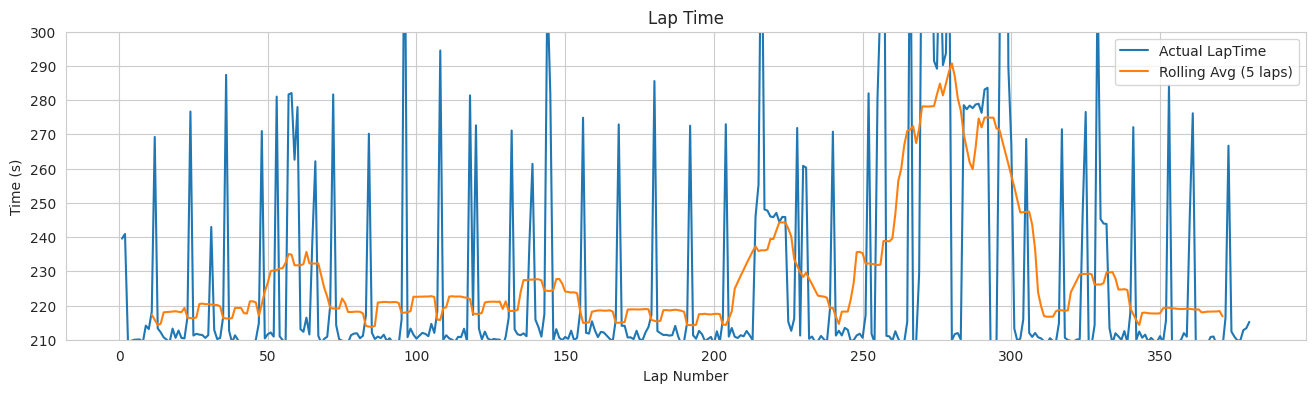

In [200]:
race_overview["lap_time_rolling"] = race_overview["lap_time"].rolling(window=20, center=True).mean()

plt.figure(figsize=(16, 4))

sns.lineplot(data=race_overview, x="lap_number", y="lap_time", label="Actual LapTime")
sns.lineplot(data=race_overview, x="lap_number", y="lap_time_rolling", label="Rolling Avg (5 laps)")

plt.title("Lap Time")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")

plt.ylim(210, 300)